In [70]:
import pandas as pd
import matplotlib.pyplot as plt
pd.reset_option('display.max_rows',None)

In [71]:
df = pd.read_csv('social_media_engagement.csv')
df.head()

,post_id,platform,post_type,post_time,likes,comments,shares,post_day,sentiment_score
0,1,Facebook,image,8/17/2023 14:45,2121,474,628,Thursday,positive
1,2,Facebook,carousel,5/14/2023 0:45,3660,432,694,Sunday,neutral
2,3,Instagram,poll,2/21/2023 16:15,4955,408,688,Tuesday,negative
3,4,Twitter,image,11/16/2023 0:45,1183,90,187,Thursday,negative
4,5,Twitter,video,5/23/2023 0:30,3499,247,286,Tuesday,positive


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   post_id          100 non-null    int64 
 1   platform         100 non-null    object
 2   post_type        100 non-null    object
 3   post_time        100 non-null    object
 4   likes            100 non-null    int64 
 5   comments         100 non-null    int64 
 6   shares           100 non-null    int64 
 7   post_day         100 non-null    object
 8   sentiment_score  100 non-null    object
dtypes: int64(4), object(5)
memory usage: 7.2+ KB


In [73]:
df['engagement'] = df['likes'] + df['comments'] + df['shares']
df['engagement']

0     3223
1     4786
2     6051
3     1460
4     4032
      ... 
95    1241
96     880
97     446
98    5704
99    4865
Name: engagement, Length: 100, dtype: int64

In [74]:
user_engagement = df.groupby('post_type')['engagement'].sum().reset_index()
user_engagement = user_engagement.sort_values('engagement',ascending=False)
print(user_engagement)

  post_type  engagement
4     video       81484
0  carousel       78799
2      poll       48703
3      text       46801
1     image       44225


    platform   engagement
0   Facebook  3423.031250
1  Instagram  3757.444444
2    Twitter  1725.218750


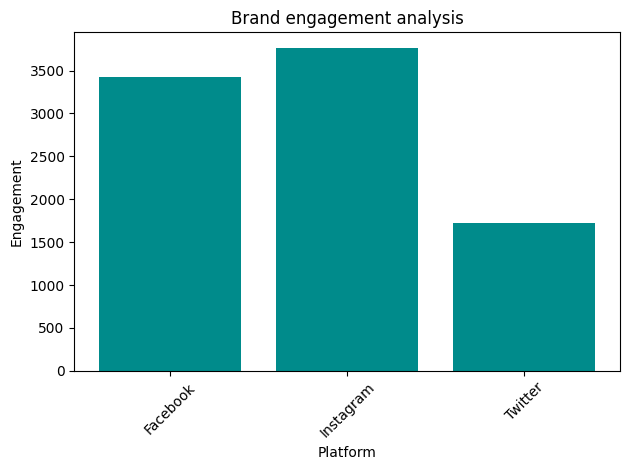

In [75]:
brandEngagement = df.groupby('platform')['engagement'].mean().reset_index()
print(brandEngagement)
plt.bar(brandEngagement['platform'],brandEngagement['engagement'],color='darkcyan')
plt.title('Brand engagement analysis')
plt.xlabel('Platform')
plt.ylabel('Engagement')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [77]:
#Top engagement post
top_post = df.loc[df['engagement'].idxmax()]
print(top_post)

post_id                       39
platform                Facebook
post_type                  video
post_time          1/1/2023 6:00
likes                       5000
comments                     430
shares                       980
post_day                  Sunday
sentiment_score          neutral
engagement                  6410
Name: 38, dtype: object


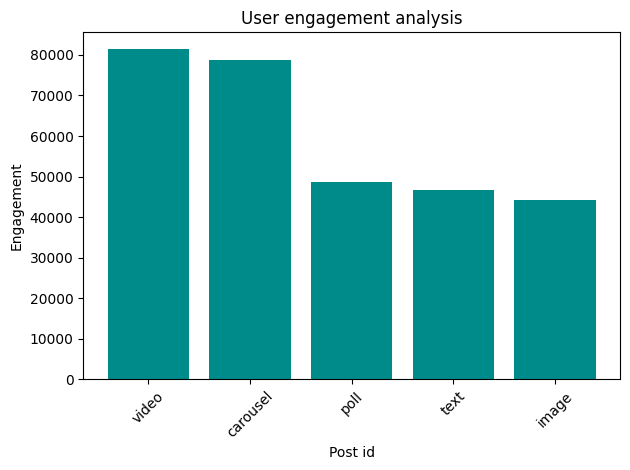

In [65]:
plt.bar(user_engagement['post_type'],user_engagement['engagement'],color='darkcyan')
plt.title('User engagement analysis')
plt.xlabel('Post Type')
plt.ylabel('Engagement')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()